# KV cache simulation — plots

Reads CSV summaries under `../results/`. Experiments write **`page_size_sweep_<dataset>.csv`** (and similarly `ordering_sweep_<dataset>.csv`, `eviction_sweep_<dataset>.csv`). The `DATASET` variable below (or env `KV_SIM_PLOT_DATASET`) must match `--dataset` when you ran the scripts; if only a legacy `*.csv` without the suffix exists, it is loaded with a notice.

Figures are **faceted by `dataset`**; **curves are split by `strategy`** (token HR solid, page HR dashed).

If one CSV mixes several runs, uncomment the `df_ps.query(...)` line in the page-size cell (and similarly for other plots).

In [25]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("..").resolve()
RES = ROOT / "results"

# Match `experiments/*.py --dataset` (or set env KV_SIM_PLOT_DATASET)
DATASET = os.environ.get("KV_SIM_PLOT_DATASET", "loogle")
DATASET = 'narrativeqa'

In [26]:
def load_csv(name: str) -> pd.DataFrame | None:
    p = RES / name
    if not p.is_file():
        print(f"Missing {p}")
        return None
    return pd.read_csv(p)


def load_sweep_csv(sweep_base: str, dataset: str | None = None) -> pd.DataFrame | None:
    """Load ``{sweep_base}_{dataset}.csv``; fall back to legacy ``{sweep_base}.csv``."""
    dataset = dataset or DATASET
    preferred = RES / f"{sweep_base}_{dataset}.csv"
    if preferred.is_file():
        return pd.read_csv(preferred)
    legacy = RES / f"{sweep_base}.csv"
    if legacy.is_file():
        print(f"Using legacy {legacy.name}")
        return pd.read_csv(legacy)
    print(f"Missing {preferred} and {legacy}")
    return None

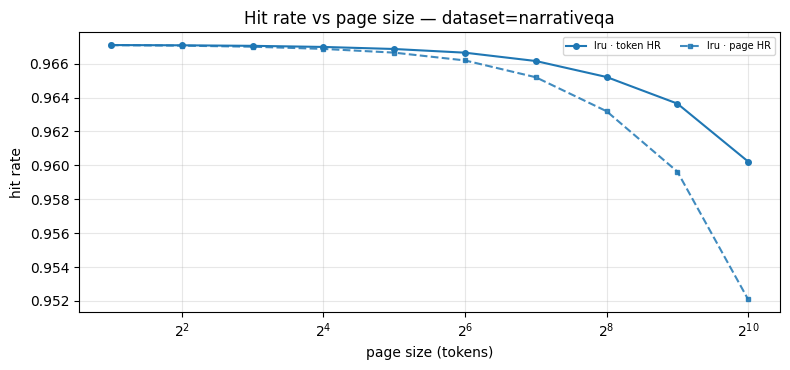

In [27]:
df_ps = load_sweep_csv("page_size_sweep")
if df_ps is not None and len(df_ps):
    # If one CSV mixes runs, narrow here, e.g.:
    # df_ps = df_ps.query("ordering == 'original' and capacity_spec == 'inf'")

    df_ps = df_ps.copy()
    df_ps["page_size"] = pd.to_numeric(df_ps["page_size"], errors="coerce")
    df_ps = df_ps.dropna(subset=["page_size"]).sort_values("page_size")

    ds_list = sorted(df_ps["dataset"].dropna().unique())
    if not ds_list:
        print("No 'dataset' column values to plot.")
    else:
        fig, axes = plt.subplots(
            len(ds_list), 1, figsize=(8, max(3.5, 3.8 * len(ds_list))), squeeze=False
        )
        cmap = plt.get_cmap("tab10")
        for ax, ds in zip(axes.ravel(), ds_list):
            sub = df_ps[df_ps["dataset"] == ds]
            strategies = sorted(sub["strategy"].dropna().unique())
            for j, strat in enumerate(strategies):
                g = sub[sub["strategy"] == strat].sort_values("page_size")
                c = cmap(j % 10)
                ax.plot(
                    g["page_size"],
                    g["token_level_hit_rate"],
                    "o-",
                    color=c,
                    label=f"{strat} · token HR",
                    ms=4,
                )
                ax.plot(
                    g["page_size"],
                    g["page_level_hit_rate"],
                    "s--",
                    color=c,
                    label=f"{strat} · page HR",
                    ms=3,
                    alpha=0.85,
                )
            ax.set_xscale("log", base=2)
            ax.set_xlabel("page size (tokens)")
            ax.set_ylabel("hit rate")
            ax.legend(loc="best", fontsize=7, ncol=2)
            ax.set_title(f"Hit rate vs page size — dataset={ds}")
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [28]:
def _capacity_rank(s) -> float:
    t = str(s).lower().replace("gb", "").strip()
    if t in ("inf", "none", "unlimited", "nan"):
        return float("inf")
    try:
        return float(t)
    except ValueError:
        return float("nan")


df_cap = load_sweep_csv("eviction_sweep")
if df_cap is not None and len(df_cap):
    # df_cap = df_cap.query("page_size == 32 and ordering == 'original'")
    df_cap = df_cap.copy()
    df_cap["_cap_r"] = df_cap["capacity_spec"].map(_capacity_rank)
    ds_list = sorted(df_cap["dataset"].dropna().unique())
    fig, axes = plt.subplots(
        len(ds_list), 1, figsize=(8, max(3.5, 3.8 * len(ds_list))), squeeze=False
    )
    cmap = plt.get_cmap("tab10")
    for ax, ds in zip(axes.ravel(), ds_list):
        sub = df_cap[df_cap["dataset"] == ds]
        caps_df = sub.drop_duplicates("capacity_spec").sort_values("_cap_r")
        xlabels = [str(x) for x in caps_df["capacity_spec"]]
        xpos = {lab: i for i, lab in enumerate(xlabels)}
        for j, strat in enumerate(sorted(sub["strategy"].dropna().unique())):
            g = sub[sub["strategy"] == strat].sort_values("_cap_r")
            xs = [xpos[str(cs)] for cs in g["capacity_spec"]]
            c = cmap(j % 10)
            ax.plot(xs, g["token_level_hit_rate"], "o-", color=c, label=strat, ms=4)
        ax.set_xticks(range(len(xlabels)))
        ax.set_xticklabels(xlabels, rotation=20, ha="right")
        ax.set_xlabel("capacity")
        ax.set_ylabel("token hit rate")
        ax.legend(title="strategy", fontsize=8)
        ax.set_title(f"Hit rate vs capacity — dataset={ds}")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Missing /data/howarli/dev/llm_prefix_caching/results/eviction_sweep_narrativeqa.csv and /data/howarli/dev/llm_prefix_caching/results/eviction_sweep.csv


In [29]:
df_ord = load_sweep_csv("ordering_sweep")
if df_ord is not None and len(df_ord):
    # df_ord = df_ord.query("page_size == 32 and capacity_spec == 'inf'")
    ds_list = sorted(df_ord["dataset"].dropna().unique())
    fig, axes = plt.subplots(
        len(ds_list), 1, figsize=(9, max(3.2, 3.5 * len(ds_list))), squeeze=False
    )
    for ax, ds in zip(axes.ravel(), ds_list):
        sub = df_ord[df_ord["dataset"] == ds]
        pivot = sub.pivot_table(
            index="ordering",
            columns="strategy",
            values="token_level_hit_rate",
            aggfunc="mean",
        )
        pivot.plot(kind="bar", ax=ax, rot=25, width=0.82)
        ax.set_ylabel("token hit rate")
        ax.set_xlabel("ordering")
        ax.legend(title="strategy", fontsize=8)
        ax.set_title(f"Hit rate by ordering — dataset={ds}")
        ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

Missing /data/howarli/dev/llm_prefix_caching/results/ordering_sweep_narrativeqa.csv and /data/howarli/dev/llm_prefix_caching/results/ordering_sweep.csv


In [30]:
# Load/compute ratio CDF: need per-request ratios from JSON (or re-run sim).
# Placeholder: CDF of per-request rates from a single detailed JSON if you export traces.
import json

json_dir = RES / "page_size_json"
if json_dir.is_dir():
    files = sorted(json_dir.glob("*.json"))
    if files:
        print("Example: inspect", files[0].name, "for future per-request CDF export.")

Example: inspect loogle_ps1024_original_lru_capinf.json for future per-request CDF export.
